> a geometric perspective

- 0113-2026：https://www.zhihu.com/question/1993698944463689134/answer/1994220570246681052 苏剑林老师 RoPE 的心路历程
    - “两个绝对位置的向量内积只依赖于相对位置“
    - Scaled Dot-Product Attention 的q、k天然具有内积结构，RoPE 的切入点
    - 彼时（BERT时代）的训练长度短，RoPE 没有竞争力
    - RoPE 流行起来，是因为随着训练长度的增加，Flash Attention “应运而生”，而 Flash Attention 的特点是，对于大多数普通用户，没法修改 Attention 内部的计算过程，而大多数相对位置编码正是通过修改 Attention 内部计算实现的，所以都被否掉了。RoPE 是以绝对位置编码的形式注入到 q、k 中的，它独立于 Attention 之外，所以成为了当时“Flash Attention + 相对位置编码”的最佳搭档。
        - 注入位置信息（在 Attention 之外）对于第 $m$ 个位置的 query 向量 $\boldsymbol{q}_m$ 和第 $n$ 个位置的 key 向量 $\boldsymbol{k}_n$，RoPE 定义了一个旋转矩阵 $\mathcal{R}$：$\boldsymbol{\tilde{q}}_m = \mathcal{R}_m \boldsymbol{q}_m, \quad \boldsymbol{\tilde{k}}_n = \mathcal{R}_n \boldsymbol{k}_n$
        - $\text{Score}_{mn} = \langle \boldsymbol{\tilde{q}}_m, \boldsymbol{\tilde{k}}_n \rangle = (\mathcal{R}_m \boldsymbol{q}_m)^T (\mathcal{R}_n \boldsymbol{k}_n) = \boldsymbol{q}_m^T \mathcal{R}_m^T \mathcal{R}_n \boldsymbol{k}_n=\boldsymbol{q}_m^T \mathcal{R}_{n-m} \boldsymbol{k}_n$
        - 点积的结果 $\boldsymbol{q}_m^T \mathcal{R}_{n-m} \boldsymbol{k}_n$ 只依赖于相对距离 $(n-m)$。

- MHA 本身是位置不敏感的，如果不引入位置信息的话
    - BV1zRSqYvEjC，Permutation Equivariance（排列等变）
    - BV1XS411P7Lc，从 RoPE 到 CoPE
- RoPE：通过绝对位置编码（赋予旋转矩阵以位置有关的绝对(absolute)旋转角度）来实现相对位置（relative）编码（rot q_m * rot k_n 向量乘机获得相对角度）
    - 相对性是数学上旋转矩阵的一个性质
$$
\underbrace{(\mathbf{R}_m \mathbf{q})^T}_{\text{旋转后的Query}} \underbrace{(\mathbf{R}_n \mathbf{k})}_{\text{旋转后的Key}} = \mathbf{q}^T \underbrace{(\mathbf{R}_m^T \mathbf{R}_n)}_{\text{核心交互}} \mathbf{k} = \mathbf{q}^T \underbrace{\mathbf{R}_{n-m}}_{\text{相对位置}} \mathbf{k}
$$
- $\theta$：刻画频率（frequencies），或者步长
    - $\theta_i=\text{base}^{-\frac{2i}d}$ （base = 10000）
        - $2i$: embedding dim 两两分组，
            - $(x_{2i},x_{2i+1}), i=[0, d/2)$，
            - $d/2$ 个二维子空间（subspaces）
            - 每个子空间对应一个旋转频率 $\theta$
        - 如何理解base：Base 定义了最慢的那个齿轮（最高维度）转一圈所需要的长度（周期）。
            - 对于低维 $i=0,\theta=1,\lambda=2\pi=6.28$，每隔约 6 个 Token，这个维度的数值就会经历一轮“上-下-上”的循环。
                - 秒针；对位置变化极度敏感。$m$ 变动 1，角度就变很大。捕捉相邻 token 的精确关系（
            - 最高维度，$i=d/2,\theta=1/10000, \lambda=2\pi\cdot 10000=62831$，
                - 时针；$m$ 变动 1，角度几乎不变；只有 $m$ 变动很大（距离很远）时，角度才有明显区别。捕捉长距离的语义关系（比如：文章开头的“张三”和文章结尾的“他”）。
            - https://huggingface.co/Qwen/Qwen3-8B/blob/main/config.json， `rope_theta=1000000`
    - 不同的维度旋转速度不同，随着维度 $i$ 增加，$\theta$ 指数级减小，旋转周期变长。
    - $m\theta=m\cdot\text{base}^{-2i/d}$：旋转矩阵的旋转角；
        - 固定 $i$，随着 $m$ 的增大，从上到下，我们看到了从高频震荡到低频缓动的渐变。
            - $i=0, \cos(m)$，每过一个 Token，它就转过很大的角度。它对位置极其敏感。
            - $i=d/2, \cos(m/10000)$，变化极其缓慢。
- 关于旋转
    - 旋转必须在一个“平面”上发生，而一个平面需要 2 个维度。为了让高维向量（比如 768 维或 4096 维）能够“旋转”，RoPE 使用了一种分治策略：它将高维空间切分为许多个独立的 2D 子空间（2D Subspaces）。
- relative distance（$R^d_{\Theta,m}$）
    -  $\text{Score}(m, n) = \mathbf{q}_m^T \mathbf{k}_n$
- token embedding seq
    - 纵向（序列中不同的 token），每一个 token 对应一个 position id（$m$）
    - 横向（embedding 中不同的 dim），每一组 pair，对应不同的 $\theta_i$
- 对 query 和 key 进行旋转位置编码（在 GQA 内部实现）
    - https://github.com/rasbt/LLMs-from-scratch/blob/main/ch05/11_qwen3/standalone-qwen3-moe.ipynb

(1000, 64)


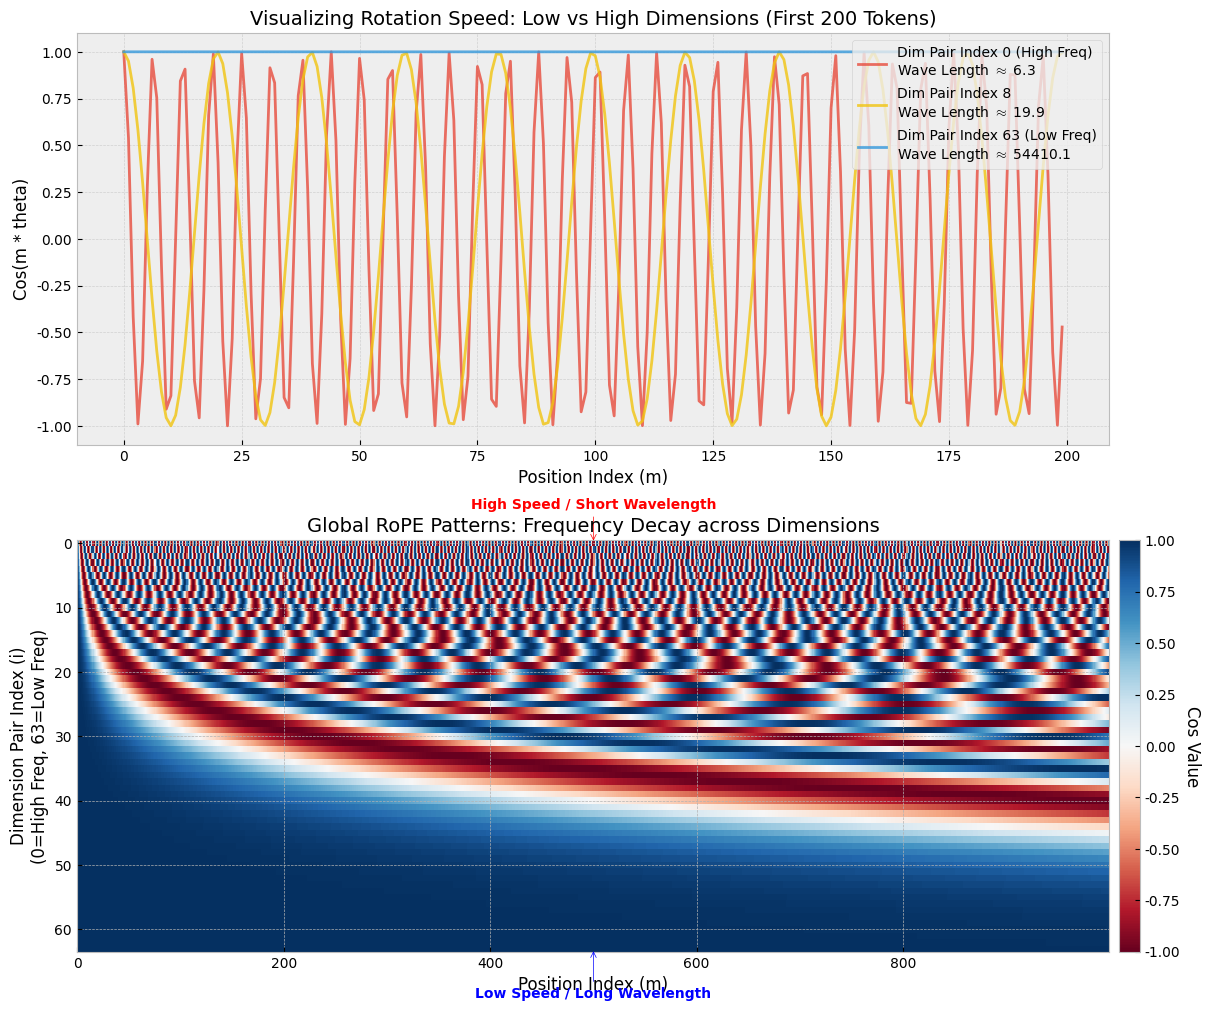

Dim Index (i)   | Theta           | Wavelength (Tokens) 
-------------------------------------------------------
0               | 1.0000          | 6.28
16              | 0.1000          | 62.83
32              | 0.0100          | 628.32
63              | 0.000115        | 54410.14


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- 1. 参数设置 ---
d_model = 128          # 模型的隐藏层维度 (embedding dimension)
n_dims = d_model // 2  # 我们只看旋转对的数量 (也就是 d/2 个频率)
seq_len = 1000         # 序列长度 (Positions)
base = 10000           # RoPE 的 base

# --- 2. 计算 RoPE 的 Theta 和 波长 ---
# 公式: theta_i = base ^ (-2i / d)
# i 是维度对的索引: 0, 1, ..., d/2-1
i_indices = np.arange(n_dims)
theta = 1.0 / (base ** (2 * i_indices / d_model))

# 计算对应的波长 lambda = 2*pi / theta
wavelengths = 2 * np.pi / theta

# 生成位置索引 m: 0, 1, ..., seq_len-1
positions = np.arange(seq_len)

# 计算位置编码矩阵 (使用 Cosine 表示旋转的实部)
# shape: (seq_len, n_dims)
# 每一列代表一个维度的旋转情况
position_encodings = np.cos(np.outer(positions, theta))
print(position_encodings.shape)

# --- 3. 可视化 ---
plt.style.use('bmh') # 使用一种清晰的绘图风格
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)

# === 图表 1: 选取几个特定维度展示波长变化 ===
# 选取 第1个(低维), 第10个(中维), 最后一个(高维)
select_indices = [0, 8, n_dims - 1] 
# select_indices = [0] 
# select_indices = [0, 8] 
# select_indices = [n_dims - 1] 
colors = ['#e74c3c', '#f1c40f', '#3498db']

for idx, dim_idx in enumerate(select_indices):
    y_values = position_encodings[:200, dim_idx] # 只看前200个位置，不然高频太密看不清
    x_subset = positions[:200]
    
    label_text = f"Dim Pair Index {dim_idx} (Low Freq)" if dim_idx == n_dims-1 else \
                 f"Dim Pair Index {dim_idx} (High Freq)" if dim_idx == 0 else \
                 f"Dim Pair Index {dim_idx}"
                 
    ax1.plot(x_subset, y_values, label=f"{label_text}\nWave Length $\\approx$ {wavelengths[dim_idx]:.1f}", 
             color=colors[idx], linewidth=2, alpha=0.8)

ax1.set_title(f"Visualizing Rotation Speed: Low vs High Dimensions (First 200 Tokens)", fontsize=14)
ax1.set_xlabel("Position Index (m)")
ax1.set_ylabel("Cos(m * theta)")
ax1.legend(loc='upper right')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# === 图表 2: 全局热力图 (Heatmap) ===
# 转置矩阵以便 X轴是位置，Y轴是维度
im = ax2.imshow(position_encodings.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1, interpolation='nearest')

ax2.set_title("Global RoPE Patterns: Frequency Decay across Dimensions", fontsize=14)
ax2.set_ylabel("Dimension Pair Index (i)\n(0=High Freq, 63=Low Freq)", fontsize=12)
ax2.set_xlabel("Position Index (m)", fontsize=12)

# 添加颜色条
cbar = fig.colorbar(im, ax=ax2, pad=0.01)
cbar.set_label("Cos Value", rotation=270, labelpad=15)

# 标注 y轴
# 也就是随着 y 增加 (向下)，颜色变化越来越慢
ax2.annotate('High Speed / Short Wavelength', xy=(seq_len/2, 0), xytext=(seq_len/2, -5),
             ha='center', va='bottom', color='red', fontweight='bold', arrowprops=dict(arrowstyle='->', color='red'))
ax2.annotate('Low Speed / Long Wavelength', xy=(seq_len/2, n_dims-1), xytext=(seq_len/2, n_dims+5),
             ha='center', va='top', color='blue', fontweight='bold', arrowprops=dict(arrowstyle='->', color='blue'))

plt.show()

# 打印具体的波长数据
print(f"{'Dim Index (i)':<15} | {'Theta':<15} | {'Wavelength (Tokens)':<20}")
print("-" * 55)
print(f"{0:<15} | {theta[0]:.4f}          | {wavelengths[0]:.2f}")
print(f"{n_dims//4:<15} | {theta[n_dims//4]:.4f}          | {wavelengths[n_dims//4]:.2f}")
print(f"{n_dims//2:<15} | {theta[n_dims//2]:.4f}          | {wavelengths[n_dims//2]:.2f}")
print(f"{n_dims-1:<15} | {theta[n_dims-1]:.6f}        | {wavelengths[n_dims-1]:.2f}")

In [46]:
2*np.pi / (np.power(10000, -2*63 / 128))

np.float64(54410.14313077675)

<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1975563/2289317151.py:38: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(x_ref, y_ref, 'k--', label='Ref: $O(\delta^{-1})$', alpha=0.5)


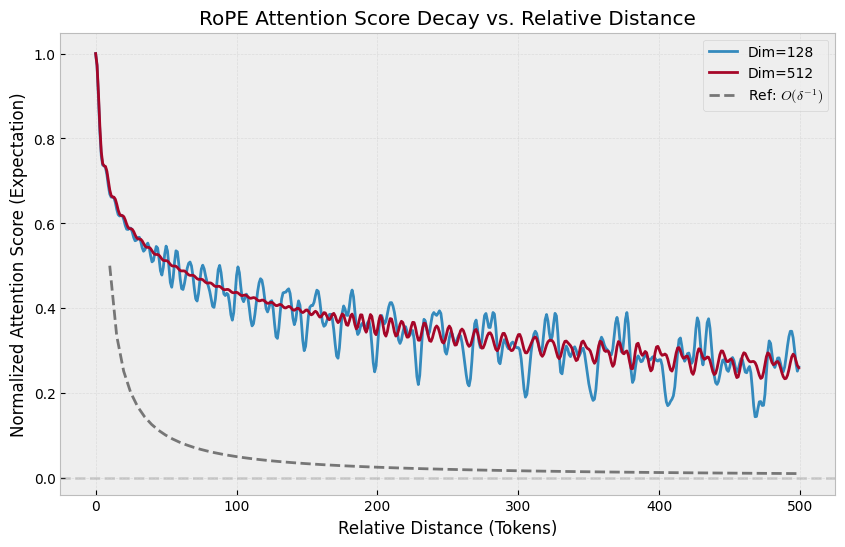

In [48]:
def quantify_rope_decay(d_model=128, max_distance=1000, base=10000):
    """
    量化 RoPE 的距离衰减特性
    """
    dim = d_model // 2
    # 生成 theta
    theta = 1.0 / (base ** (2 * np.arange(dim) / d_model))
    
    decay_scores = []
    distances = np.arange(max_distance)
    
    # 我们只关心旋转带来的衰减，所以假设 q 和 k 初始是完全对齐的单位向量
    # 这样 score(0) 应该是 1 (最大值)
    # Score(delta) = sum(cos(delta * theta)) / dim
    
    for delta in distances:
        # 计算所有维度的余弦值
        cos_values = np.cos(delta * theta)
        
        # RoPE 的核心衰减来源于这些余弦值的平均
        # 如果大家方向一致，均值为1；如果方向乱了，均值趋向于0
        avg_score = np.mean(cos_values) 
        decay_scores.append(avg_score)
        
    return distances, decay_scores

# 运行模拟
d_models = [128, 512]
plt.figure(figsize=(10, 6))

for d in d_models:
    x, y = quantify_rope_decay(d_model=d, max_distance=500)
    plt.plot(x, y, label=f'Dim={d}')

# 添加一条 1/x 的参考线来看看是否符合幂律衰减
x_ref = np.linspace(10, 500, 100)
y_ref = 5 / x_ref # 简单的缩放以便对比
plt.plot(x_ref, y_ref, 'k--', label='Ref: $O(\delta^{-1})$', alpha=0.5)

plt.axhline(0, color='gray', linestyle='--', alpha=0.3)
plt.title("RoPE Attention Score Decay vs. Relative Distance")
plt.xlabel("Relative Distance (Tokens)")
plt.ylabel("Normalized Attention Score (Expectation)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### implementation

- query, key: $b\times t\times d$
- cis（cos i sin）: $e^{i\theta} = \cos \theta + i \sin \theta$
    - 如果我们把一个二维向量 $(x, y)$ 看作复数 $z = x + iy$，那么旋转角度 $\theta$ 可以表示为：
        - $z' = z \cdot e^{i\theta} = (x + iy) \cdot (\cos \theta + i \sin \theta)=(x \cos \theta - y \sin \theta) + i(x \sin \theta + y \cos \theta)$
    - 矩阵实数视角
$$
\begin{pmatrix} x' \\ y' \end{pmatrix} = \begin{pmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix}
$$

$$
R^d_{\Theta,T}
$$

In [58]:
def compute_rope_params(head_dim, theta_base=10_000, context_length=4096, dtype=torch.float32):
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, dtype=dtype)[: (head_dim // 2)].float() / head_dim))

    # Generate position indices
    positions = torch.arange(context_length, dtype=dtype)

    # Compute the angles
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin

https://kexue.fm/archives/8265
- `angles = torch.cat([angles, angles], dim=1)`
    - $[\cos \theta_0, \dots, \cos \theta_{d/2-1}, \cos \theta_0, \dots, \cos \theta_{d/2-1}]$
- $\text{rotate\_half}(x) = [-x_{d/2}, -x_{d/2+1}, \dots, x_0, x_1, \dots]$

$$
\begin{equation}
\underbrace{
\begin{pmatrix}
q_0 \\ \vdots \\ q_{h-1} \\
\hdashline
q_{h} \\ \vdots \\ q_{d-1}
\end{pmatrix}
}_{\text{原始 } q}
\otimes
\underbrace{
\begin{pmatrix}
\cos m\theta_0 \\ \vdots \\ \cos m\theta_{h-1} \\
\hdashline
\cos m\theta_0 \\ \vdots \\ \cos m\theta_{h-1}
\end{pmatrix}
}_{\text{ } \cos \text{ (cat 之后)}}
+
\underbrace{
\begin{pmatrix}
-q_{h} \\ \vdots \\ -q_{d-1} \\
\hdashline
q_0 \\ \vdots \\ q_{h-1}
\end{pmatrix}
}_{\text{rotate\_half}(q)}
\otimes
\underbrace{
\begin{pmatrix}
\sin m\theta_0 \\ \vdots \\ \sin m\theta_{h-1} \\
\hdashline
\sin m\theta_0 \\ \vdots \\ \sin m\theta_{h-1}
\end{pmatrix}
}_{\text{ } \sin \text{ (cat 之后)}}
\end{equation}
$$

- $h=d/2$，$(q_0, q_{d/2})$ 是一对；非 interleaved 的
    - Interleaved 版本是 $q_0, q_1$ 是一组； 

In [52]:
HEAD_DIM = 64 
CONTEXT_LEN = 5 
BASE = 10000

cos, sin = compute_rope_params(
        head_dim=HEAD_DIM, 
        theta_base=BASE, 
        context_length=CONTEXT_LEN
    )

In [54]:
cos.shape, sin.shape

(torch.Size([5, 64]), torch.Size([5, 64]))

In [55]:
# token 0
# cos(0) = 1, sin(0) = 0 
cos[0, :], sin[0, :]

(tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [56]:
# token 1
cos[1, :], sin[1, :]

(tensor([0.5403, 0.7318, 0.8460, 0.9124, 0.9504, 0.9720, 0.9842, 0.9911, 0.9950,
         0.9972, 0.9984, 0.9991, 0.9995, 0.9997, 0.9998, 0.9999, 0.9999, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.5403, 0.7318, 0.8460, 0.9124,
         0.9504, 0.9720, 0.9842, 0.9911, 0.9950, 0.9972, 0.9984, 0.9991, 0.9995,
         0.9997, 0.9998, 0.9999, 0.9999, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000]),
 tensor([8.4147e-01, 6.8156e-01, 5.3317e-01, 4.0931e-01, 3.1098e-01, 2.3492e-01,
         1.7689e-01, 1.3296e-01, 9.9833e-02, 7.4919e-02, 5.6204e-02, 4.2157e-02,
         3.1618e-02, 2.3712e-02, 1.7782e-02, 1.3335e-02, 9.9998e-03, 7.4989e-03,
         5.6234e-03, 4.2170e-03, 3.1623e-03, 2.3714e-03, 1.7783e-03, 1.3335e-03,
         1.0000e-03, 7.4989e-04, 5.6234e-04, 4.2170e-04, 3.1623e-04, 2.3714e-04,
         

In [57]:
import torch

# === 1. 定义你的函数 (Real-valued Approach) ===
def compute_rope_params(head_dim, theta_base=10_000, context_length=4096):
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    positions = torch.arange(context_length)
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)
    # 关键点：这里采用了 cat，对应 Half-split 模式
    angles = torch.cat([angles, angles], dim=1) 
    cos = torch.cos(angles)
    sin = torch.sin(angles)
    return cos, sin

def rotate_half(x):
    """LLaMA/HuggingFace 风格的旋转辅助函数"""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)

def apply_rope_real(x, cos, sin):
    # 这里的公式 = x * cos - y * sin (利用 rotate_half 里的负号实现了减法)
    return (x * cos) + (rotate_half(x) * sin)

# === 2. 定义复数函数 (Complex Approach) ===
def apply_rope_complex(x, head_dim, theta_base=10_000):
    # 重塑为复数形式 (B, L, H/2)
    # 注意：为了配合上面的 Half-split 模式，我们需要先重排 x
    # 将前半部分作为实部，后半部分作为虚部
    x1 = x[..., : head_dim // 2]
    x2 = x[..., head_dim // 2 :]
    x_complex = torch.complex(x1, x2)
    
    # 生成复数旋转算子
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    positions = torch.arange(x.shape[1])
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0) # (L, H/2)
    rope_complex = torch.polar(torch.ones_like(angles), angles) # 模长为1，幅角为angles
    
    # 复数乘法: (x + iy) * e^{i\theta}
    x_out_complex = x_complex * rope_complex
    
    # 变回实数并拼接回 (B, L, H)
    return torch.cat([x_out_complex.real, x_out_complex.imag], dim=-1)

# === 3. 验证等价性 ===
torch.manual_seed(42)
HEAD_DIM = 64
SEQ_LEN = 5
BATCH = 1
BASE = 10000

# 模拟输入向量 Query
x = torch.randn(BATCH, SEQ_LEN, HEAD_DIM)

# 方法 A：使用你的实数代码
cos, sin = compute_rope_params(HEAD_DIM, BASE, SEQ_LEN)
# 扩充维度以匹配 batch
cos = cos.unsqueeze(0)
sin = sin.unsqueeze(0)
out_real = apply_rope_real(x, cos, sin)

# 方法 B：使用复数代码
out_complex = apply_rope_complex(x, HEAD_DIM, BASE)

# 比较
print(f"Max Difference: {(out_real - out_complex).abs().max().item()}")
assert torch.allclose(out_real, out_complex, atol=1e-6)
print("验证通过：两种方式数学等价。")

Max Difference: 2.384185791015625e-07
验证通过：两种方式数学等价。


```python
cos, sin = compute_rope_params(
    head_dim=head_dim,
    theta_base=cfg["rope_base"],
    context_length=cfg["context_length"]
)

# Apply projections
queries = self.W_query(x)  # (b, num_tokens, num_heads * head_dim)
keys = self.W_key(x)       # (b, num_tokens, num_kv_groups * head_dim)
values = self.W_value(x)   # (b, num_tokens, num_kv_groups * head_dim)

# Reshape
queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
keys = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)
values = values.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)

queries = apply_rope(queries, cos, sin)
keys = apply_rope(keys, cos, sin)
```